# Part 1: v-Prediction Flow Matching at `D = 2`

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

### Helper Functions

In [2]:
def scatter_plot(data, title="Scatter Plot"):
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=10)
    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def loss_plot(loss, title="Training Loss", log_scale=True):
    epochs, values = zip(*loss)
    
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, values)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    if log_scale:
        plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
device = torch.device('cuda')

step    500/25000  loss 1.085350
step   1000/25000  loss 1.011585
step   1500/25000  loss 0.996816
step   2000/25000  loss 0.975557
step   2500/25000  loss 0.967031
step   3000/25000  loss 0.961494
step   3500/25000  loss 0.958333
step   4000/25000  loss 0.960121
step   4500/25000  loss 0.952798
step   5000/25000  loss 0.954510
step   5500/25000  loss 0.952285
step   6000/25000  loss 0.956533
step   6500/25000  loss 0.953840
step   7000/25000  loss 0.955127
step   7500/25000  loss 0.953849
step   8000/25000  loss 0.953279
step   8500/25000  loss 0.954836
step   9000/25000  loss 0.950392
step   9500/25000  loss 0.950167
step  10000/25000  loss 0.949078
step  10500/25000  loss 0.953769
step  11000/25000  loss 0.947693
step  11500/25000  loss 0.949300
step  12000/25000  loss 0.950312
step  12500/25000  loss 0.949810
step  13000/25000  loss 0.949732
step  13500/25000  loss 0.948744
step  14000/25000  loss 0.949412
step  14500/25000  loss 0.946999
step  15000/25000  loss 0.948104
step  1550

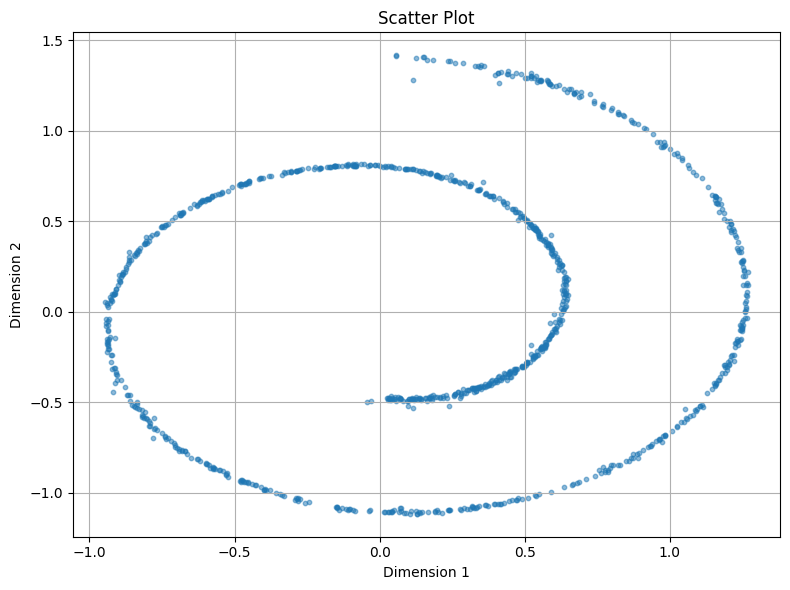

In [7]:
# Dataloader
dataloader = get_dataloader(name="swiss_roll", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(1024, 'v', device)
scatter_plot(out.cpu())

step    500/25000  loss 1.061231
step   1000/25000  loss 0.943820
step   1500/25000  loss 0.930333
step   2000/25000  loss 0.921277
step   2500/25000  loss 0.922362
step   3000/25000  loss 0.916241
step   3500/25000  loss 0.915158
step   4000/25000  loss 0.916737
step   4500/25000  loss 0.917005
step   5000/25000  loss 0.911674
step   5500/25000  loss 0.915660
step   6000/25000  loss 0.913385
step   6500/25000  loss 0.916858
step   7000/25000  loss 0.910908
step   7500/25000  loss 0.913543
step   8000/25000  loss 0.909903
step   8500/25000  loss 0.911947
step   9000/25000  loss 0.911224
step   9500/25000  loss 0.910769
step  10000/25000  loss 0.911995
step  10500/25000  loss 0.912102
step  11000/25000  loss 0.908117
step  11500/25000  loss 0.907745
step  12000/25000  loss 0.907262
step  12500/25000  loss 0.908707
step  13000/25000  loss 0.908609
step  13500/25000  loss 0.910048
step  14000/25000  loss 0.908525
step  14500/25000  loss 0.907580
step  15000/25000  loss 0.906194
step  1550

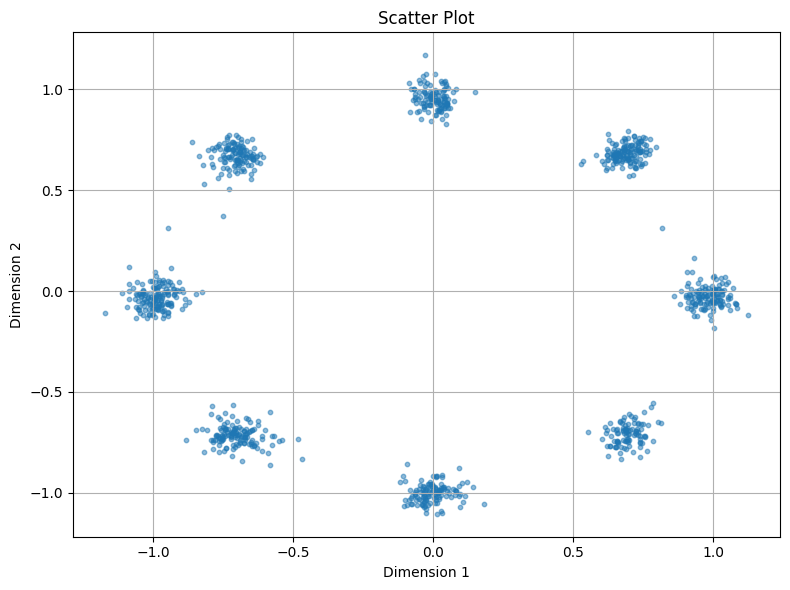

In [8]:
# Dataloader
dataloader = get_dataloader(name="gaussians", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(1024, 'v', device)
scatter_plot(out.cpu())

step    500/25000  loss 0.930464
step   1000/25000  loss 0.873088
step   1500/25000  loss 0.869014
step   2000/25000  loss 0.864128
step   2500/25000  loss 0.865272
step   3000/25000  loss 0.862017
step   3500/25000  loss 0.857788
step   4000/25000  loss 0.849462
step   4500/25000  loss 0.848997
step   5000/25000  loss 0.845012
step   5500/25000  loss 0.844724
step   6000/25000  loss 0.844337
step   6500/25000  loss 0.841307
step   7000/25000  loss 0.840569
step   7500/25000  loss 0.841396
step   8000/25000  loss 0.843232
step   8500/25000  loss 0.839640
step   9000/25000  loss 0.840204
step   9500/25000  loss 0.839809
step  10000/25000  loss 0.839434
step  10500/25000  loss 0.841251
step  11000/25000  loss 0.840846
step  11500/25000  loss 0.841271
step  12000/25000  loss 0.840903
step  12500/25000  loss 0.839569
step  13000/25000  loss 0.842756
step  13500/25000  loss 0.839786
step  14000/25000  loss 0.837591
step  14500/25000  loss 0.837821
step  15000/25000  loss 0.839444
step  1550

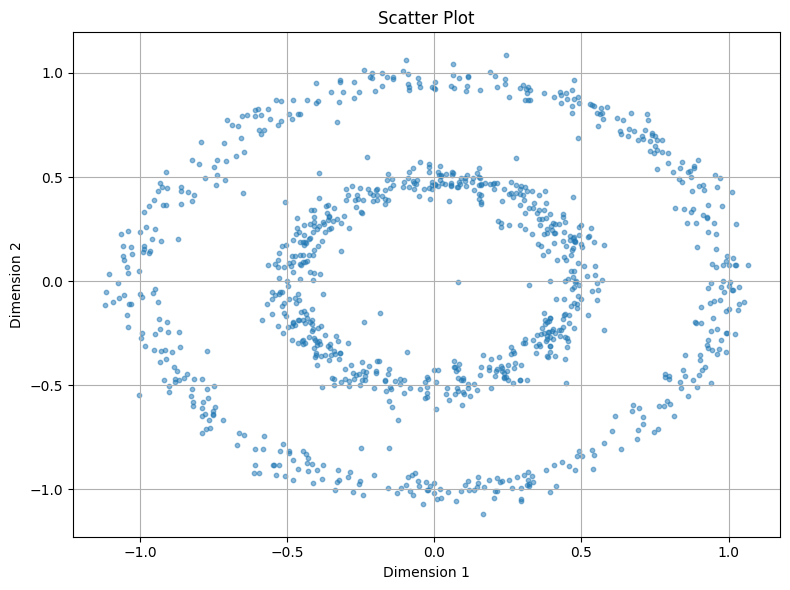

In [9]:
# Dataloader
dataloader = get_dataloader(name="circles", dim=2, batch_size=1024)
# MLP Model
model = JiM(hidden_dim=256, D=2)
model = model.to(device)
# Optimiser
opt = optim.Adam(model.parameters(), lr=1e-3)
# Train Steps
train_steps = 25000
# Denoising steps
steps = 50

# Train
loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

# Generate
denoiser = Denoiser(model, steps=steps, D=2)
out = denoiser.generate(1024, 'v', device)
scatter_plot(out.cpu())